In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/RTYB201920_A1_6.csv")

In [ ]:
df.head() # Views first 5 rows

,Year,Freight (Billion Tonnes km),Passenger (Billion Passengers km),GDP Growth Rate used
0,1999-2000,467.0,1832,0.080
1,2000-01,494.0,2076,0.041
2,2001-02,515.0,2413,0.054
3,2002-03,545.0,2815,0.039
4,2003-04,595.0,3070,0.080


In [ ]:
df.shape # Check number of rows and columns

(21, 4)

In [ ]:
df.info() # Check data types, missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 4 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Year                               21 non-null     object 
 1   Freight (Billion Tonnes km)        21 non-null     float64
 2   Passenger (Billion Passengers km)  21 non-null     int64  
 3   GDP Growth Rate used               21 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 804.0+ bytes


In [ ]:
df.describe() # Get Statistical summary

,Freight (Billion Tonnes km),Passenger (Billion Passengers km),GDP Growth Rate used
count,21.000000,21.000000,21.000000
mean,1333.290476,9439.904762,0.071714
std,779.064572,7177.001525,0.016386
min,467.000000,1832.000000,0.039000
25%,643.000000,3469.000000,0.061000
50%,1144.500000,7192.000000,0.071000
75%,1823.200000,13393.000000,0.083000
max,2927.300000,25199.000000,0.096000


In [ ]:
df.columns = [
    "year",
    "freight_billion_tkm",
    "passenger_billion_pkm",
    "gdp_growth_rate"
]

In [ ]:
df["year"] = df["year"].astype(str)
df["year"] = df["year"].str[:4]
df["year"] = pd.to_numeric(df["year"])

In [ ]:
df.head()

,year,freight_billion_tkm,passenger_billion_pkm,gdp_growth_rate
0,1999,467.0,1832,0.080
1,2000,494.0,2076,0.041
2,2001,515.0,2413,0.054
3,2002,545.0,2815,0.039
4,2003,595.0,3070,0.080


In [ ]:
df.isnull().sum()

,0
year,0
freight_billion_tkm,0
passenger_billion_pkm,0
gdp_growth_rate,0


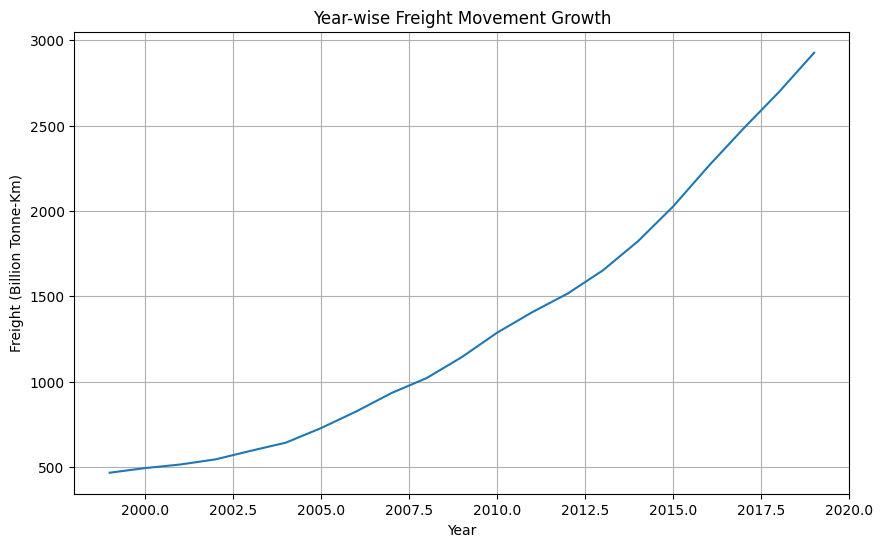

In [ ]:
# Exploratory Data Analysis
# Freight Movement over time
plt.figure(figsize=(10,6))
plt.plot(df["year"], df["freight_billion_tkm"])
plt.xlabel("Year")
plt.ylabel("Freight (Billion Tonne-Km)")
plt.title("Year-wise Freight Movement Growth")
plt.grid(True)
plt.show()

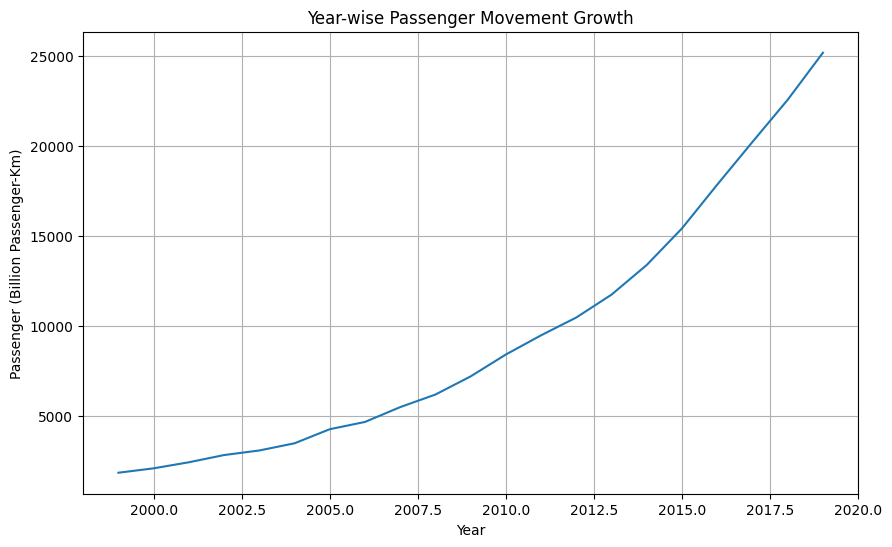

In [ ]:
# Passenger Trend Analysis
plt.figure(figsize=(10,6))
plt.plot(df["year"], df["passenger_billion_pkm"])
plt.xlabel("Year")
plt.ylabel("Passenger (Billion Passenger-Km)")
plt.title("Year-wise Passenger Movement Growth")
plt.grid(True)
plt.show()

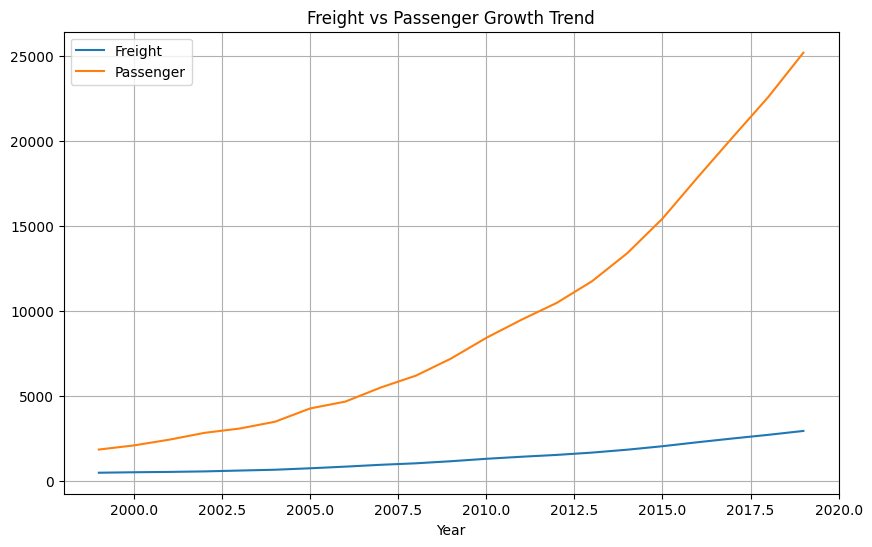

In [ ]:
# Freight Vs Passenger Comparison
plt.figure(figsize=(10,6))
plt.plot(df["year"], df["freight_billion_tkm"], label="Freight")
plt.plot(df["year"], df["passenger_billion_pkm"], label="Passenger")
plt.xlabel("Year")
plt.title("Freight vs Passenger Growth Trend")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Growth Rate Analysis
df["freight_growth"] = df["freight_billion_tkm"].pct_change() * 100
df["passenger_growth"] = df["passenger_billion_pkm"].pct_change() * 100

df.head()

,year,freight_billion_tkm,passenger_billion_pkm,gdp_growth_rate,freight_growth,passenger_growth
0,1999,467.0,1832,0.080,NaN,NaN
1,2000,494.0,2076,0.041,5.781585,13.318777
2,2001,515.0,2413,0.054,4.251012,16.233141
3,2002,545.0,2815,0.039,5.825243,16.659760
4,2003,595.0,3070,0.080,9.174312,9.058615


In [ ]:
# Correlation Analysis
df[["freight_billion_tkm",
    "passenger_billion_pkm",
    "gdp_growth_rate"]].corr()

,freight_billion_tkm,passenger_billion_pkm,gdp_growth_rate
freight_billion_tkm,1.000000,0.997296,-0.022898
passenger_billion_pkm,0.997296,1.000000,-0.046581
gdp_growth_rate,-0.022898,-0.046581,1.000000


In [ ]:
# Build regression Model(Freight)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Independent variable (Year)
X = df[["year"]]

# Dependent variable (Freight)
y = df["freight_billion_tkm"]

# Create model
freight_model = LinearRegression()

# Train model
freight_model.fit(X, y)

# Get slope & intercept
print("Intercept:", freight_model.intercept_)
print("Slope:", freight_model.coef_[0])

Intercept: -243111.9149783549
Slope: 121.6750649350649


In [ ]:
# Model Accuracy
from sklearn.metrics import r2_score

freight_pred = freight_model.predict(X)
r2 = r2_score(y, freight_pred)

print("R² Score:", r2)

R² Score: 0.9391111409290833


In [ ]:
# Future Prediction
future_years = pd.DataFrame({
    "year": np.arange(df["year"].max() + 1, 2031)
})

future_years

,year
0,2020
1,2021
2,2022
3,2023
4,2024
5,2025
6,2026
7,2027
8,2028
9,2029


In [ ]:
future_years["predicted_freight"] = freight_model.predict(future_years)

future_years

,year,predicted_freight
0,2020,2671.716190
1,2021,2793.391255
2,2022,2915.066320
3,2023,3036.741385
4,2024,3158.416450
5,2025,3280.091515
6,2026,3401.766580
7,2027,3523.441645
8,2028,3645.116710
9,2029,3766.791775


In [ ]:
df["year"].max()

2019

In [ ]:
# Build Regression Model(Passenger)
# Define dependent variable (Passenger)
y_passenger = df["passenger_billion_pkm"]

# Create model
passenger_model = LinearRegression()

# Train model
passenger_model.fit(X, y_passenger)

# Print equation values
print("Intercept:", passenger_model.intercept_)
print("Slope:", passenger_model.coef_[0])

Intercept: -2201819.4316017306
Slope: 1100.676623376623


In [ ]:
# Model Accuracy
passenger_pred = passenger_model.predict(X)

from sklearn.metrics import r2_score
r2_passenger = r2_score(y_passenger, passenger_pred)

print("Passenger R² Score:", r2_passenger)

Passenger R² Score: 0.9055118501728768


In [ ]:
# Future Prediction
future_years

,year,predicted_freight
0,2020,2671.716190
1,2021,2793.391255
2,2022,2915.066320
3,2023,3036.741385
4,2024,3158.416450
5,2025,3280.091515
6,2026,3401.766580
7,2027,3523.441645
8,2028,3645.116710
9,2029,3766.791775


In [ ]:
future_years["predicted_passenger"] = passenger_model.predict(future_years[["year"]])

future_years

,year,predicted_freight,predicted_passenger
0,2020,2671.716190,21547.347619
1,2021,2793.391255,22648.024242
2,2022,2915.066320,23748.700866
3,2023,3036.741385,24849.377489
4,2024,3158.416450,25950.054113
5,2025,3280.091515,27050.730736
6,2026,3401.766580,28151.407359
7,2027,3523.441645,29252.083983
8,2028,3645.116710,30352.760606
9,2029,3766.791775,31453.437229


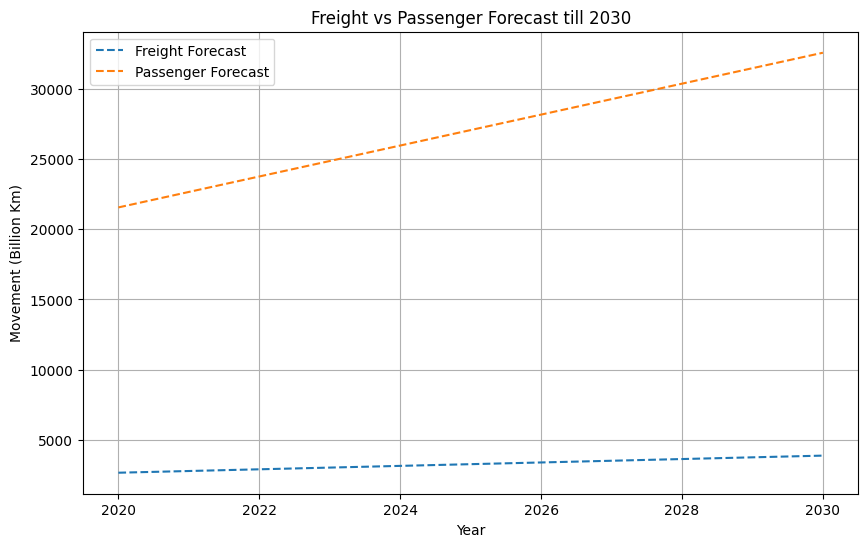

In [ ]:
plt.figure(figsize=(10,6))

# Freight forecast
plt.plot(future_years["year"], future_years["predicted_freight"],
         label="Freight Forecast", linestyle="dashed")

# Passenger forecast
plt.plot(future_years["year"], future_years["predicted_passenger"],
         label="Passenger Forecast", linestyle="dashed")

plt.xlabel("Year")
plt.ylabel("Movement (Billion Km)")
plt.title("Freight vs Passenger Forecast till 2030")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Loading Toll Revenue Dataset
rev_df = pd.read_csv("/content/RS_Session_265_AU_1078_D.csv")

rev_df.head()

,Sl. No.,Fee Plaza,Type (PF/BOT/TOT/OMT),State,Total Fee Collection - 2019-20,Total Fee Collection - 2020-21,Total Fee Collection - 2021-22,Total Fee Collection - 2022-23,Total Fee Collection - 2023-24,Total Collection for Last 05 Financial Years
0,1,Bharthana,PF,Gujarat,357.91,338.57,418.73,455.94,472.65,2043.80
1,2,Shahjahanpur,BOT,Rajasthan,392.92,300.48,320.42,440.99,429.65,1884.45
2,3,Jaladhulagori,BOT,West Bengal,260.11,257.72,291.85,365.00,364.23,1538.91
3,4,Barajore,BOT,Uttar Pradesh,232.44,251.88,298.68,333.06,364.69,1480.74
4,5,Gharonda,PF,Haryana,297.60,163.78,100.38,352.35,400.26,1314.37


In [ ]:
rev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Sl. No.                                       20 non-null     int64  
 1   Fee Plaza                                     20 non-null     object 
 2   Type (PF/BOT/TOT/OMT)                         20 non-null     object 
 3   State                                         20 non-null     object 
 4   Total Fee Collection - 2019-20                20 non-null     float64
 5   Total Fee Collection - 2020-21                20 non-null     float64
 6   Total Fee Collection - 2021-22                20 non-null     float64
 7   Total Fee Collection - 2022-23                20 non-null     float64
 8   Total Fee Collection - 2023-24                20 non-null     float64
 9   Total Collection for Last 05 Financial Years  20 non-null     float

In [ ]:
# Data Preprocessing - Renamimg Columns
rev_df.columns = [
    "sl_no",
    "fee_plaza",
    "type",
    "state",
    "revenue_2019",
    "revenue_2020",
    "revenue_2021",
    "revenue_2022",
    "revenue_2023",
    "total_5yr_revenue"
]

rev_df.head()

,sl_no,fee_plaza,type,state,revenue_2019,revenue_2020,revenue_2021,revenue_2022,revenue_2023,total_5yr_revenue
0,1,Bharthana,PF,Gujarat,357.91,338.57,418.73,455.94,472.65,2043.80
1,2,Shahjahanpur,BOT,Rajasthan,392.92,300.48,320.42,440.99,429.65,1884.45
2,3,Jaladhulagori,BOT,West Bengal,260.11,257.72,291.85,365.00,364.23,1538.91
3,4,Barajore,BOT,Uttar Pradesh,232.44,251.88,298.68,333.06,364.69,1480.74
4,5,Gharonda,PF,Haryana,297.60,163.78,100.38,352.35,400.26,1314.37


In [ ]:
# Identify Top revenue generating Toll Plazas
rev_df.sort_values(by="total_5yr_revenue", ascending=False).head(5)

,sl_no,fee_plaza,type,state,revenue_2019,revenue_2020,revenue_2021,revenue_2022,revenue_2023,total_5yr_revenue
0,1,Bharthana,PF,Gujarat,357.91,338.57,418.73,455.94,472.65,2043.80
1,2,Shahjahanpur,BOT,Rajasthan,392.92,300.48,320.42,440.99,429.65,1884.45
2,3,Jaladhulagori,BOT,West Bengal,260.11,257.72,291.85,365.00,364.23,1538.91
3,4,Barajore,BOT,Uttar Pradesh,232.44,251.88,298.68,333.06,364.69,1480.74
4,5,Gharonda,PF,Haryana,297.60,163.78,100.38,352.35,400.26,1314.37


In [ ]:
# State-wise Revenue Analysis
state_revenue = rev_df.groupby("state")["total_5yr_revenue"].sum()

state_revenue.sort_values(ascending=False)

,total_5yr_revenue
state,
Gujarat,6254.24
Rajasthan,4028.36
Uttar Pradesh,3588.96
Tamil Nadu,2105.75
West Bengal,1538.91
Haryana,1314.37
Bihar,1071.37
Maharashtra,1026.13
Odisha,947.22


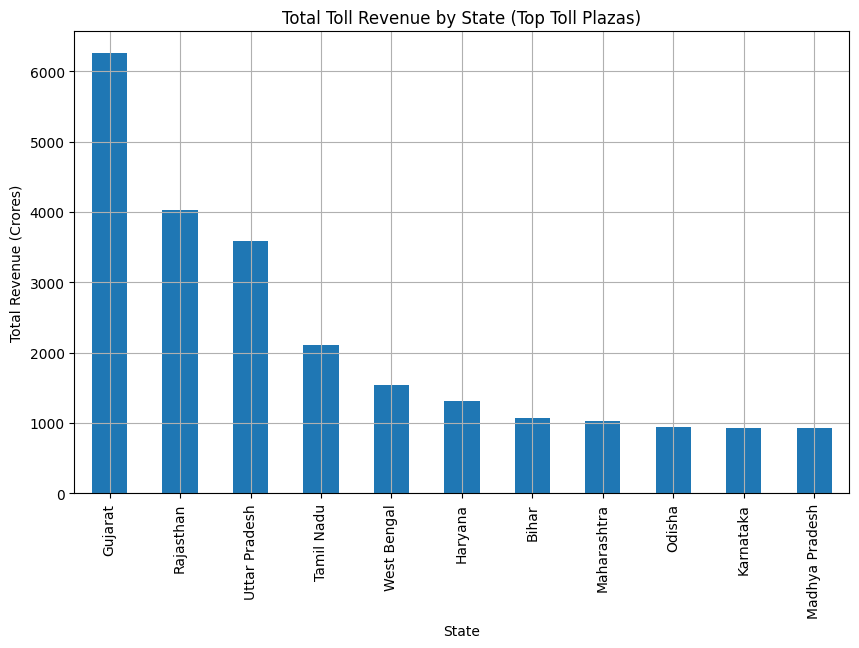

In [ ]:
# Visualizing State Revenue
import matplotlib.pyplot as plt

state_revenue.sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Total Toll Revenue by State (Top Toll Plazas)")
plt.xlabel("State")
plt.ylabel("Total Revenue (Crores)")
plt.grid(True)
plt.show()

In [ ]:
# Connecting Transport Demand with toll Revenue
# 7.1 Calculate Average Toll Revenue Per year
yearly_revenue = rev_df[[
    "revenue_2019",
    "revenue_2020",
    "revenue_2021",
    "revenue_2022",
    "revenue_2023"
]].mean()

yearly_revenue

,0
revenue_2019,213.32395
revenue_2020,187.61635
revenue_2021,220.34495
revenue_2022,274.59900
revenue_2023,291.42050


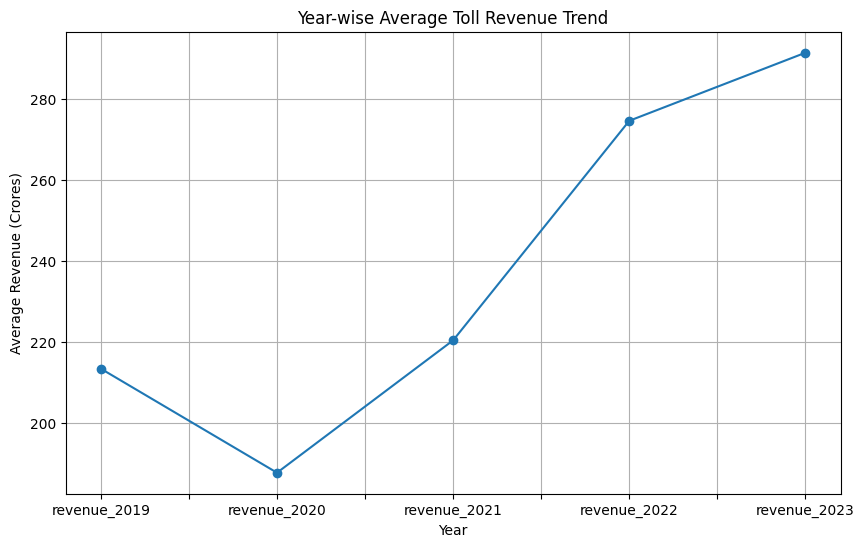

In [ ]:
# 7.2 Plot Year-wise Toll Revenue Trend
import matplotlib.pyplot as plt

yearly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.title("Year-wise Average Toll Revenue Trend")
plt.xlabel("Year")
plt.ylabel("Average Revenue (Crores)")
plt.grid(True)
plt.show()